In [1]:
import scipy
import random
import numpy as np
import pandas as pd
#import seaborn as sns
from matplotlib import pyplot as plt
from numba import jit

from scipy.stats import ks_1samp
from scipy.stats import norm, kstest
from scipy.stats import kstest
from scipy.stats import ttest_ind
from scipy.stats import ks_2samp
from scipy.stats import gaussian_kde

from scipy.optimize import minimize
from scipy.spatial import distance
from scipy.integrate import quad

from source.distributions import *
from source.plot_tools import *
from source.analysis_tools import *

In [2]:
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Arial']})
# rc('text', usetex=True)
plt.rcParams['xtick.labelsize']=15
plt.rcParams['ytick.labelsize']=15
plt.rcParams['font.size']=15
plt.rcParams['pdf.fonttype']=42
plt.rcParams["text.usetex"]=False

# Analysis of control and inhibition experiments

In [3]:
micron_per_pixel = 1.0/23.5 # Value from Salman

original = pd.read_csv('Data/transcriptional_inhibition_data.csv')
dataset  = pd.DataFrame()

dataset['spot_id']    = original['spot_id']

# populate a list of FC radii
dataset['radius']     = (original['pixels'] / np.pi)**0.5 * micron_per_pixel
dataset['diameter']   = 2*dataset['radius']

# populate a list of tuples that correspond to the centroid coordinates
dataset['coordinate'] = list(original[['centroid_r', 'centroid_c']].to_numpy() * micron_per_pixel)

# get keywords
dataset["sample"]      = original["sample"]
dataset['sample_type'] = [val[0].capitalize() for val in original['sample'].str.split('-')]

# infer nucleus IDs by clustering
for sample in dataset['sample'].unique():
    mask = dataset['sample'] == sample
    dataset.loc[mask, "nuc_id"] = cluster(np.stack(dataset.loc[mask, 'coordinate']), epsilon = 2.0, min_samples = 3)
dataset["nuc_id"] = dataset["nuc_id"].astype(np.int64)

dataset.head()

,spot_id,radius,diameter,coordinate,sample,sample_type,nuc_id
0,1,0.110019,0.220038,"[0.0425531914893617, 41.234042553191486]",Control-roi-01,Control,0
1,2,0.115139,0.230277,"[0.0425531914893617, 44.8936170212766]",Control-roi-01,Control,0
2,3,0.115139,0.230277,"[0.1276595744680851, 43.361702127659576]",Control-roi-01,Control,0
3,4,0.107367,0.214735,"[0.2127659574468085, 41.61702127659574]",Control-roi-01,Control,0
4,5,0.072024,0.144048,"[0.1702127659574468, 44.212765957446805]",Control-roi-01,Control,0


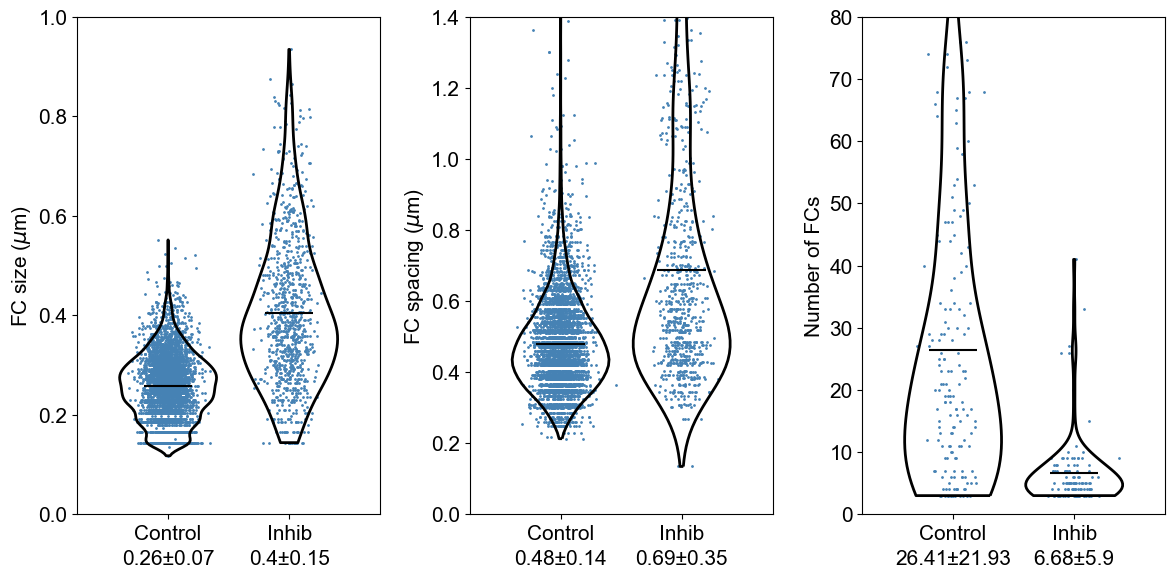

In [4]:
# Plot violin plot of the data
fig, axs = plt.subplots(1, 3, figsize=(12,6))

# plot diameter distribution
diameters = dataset.groupby("sample_type").diameter.apply(list)
plot_violin(axs[0], diameters, r'FC size ($\mu$m)', [0,1.0])

# plot distance distribution
filtered_dataset = dataset[dataset["nuc_id"]>=0]

# In contrast to 3D_Statistics_and_Distribution.ipynb, where nucleoli were called manually,
# here the nucleoli are called by automatic clustering. This can lead to artifacts, where FCs are not part
# of any nucleolus. For that reason, in this notebook I filter out the FCs that are not part of nucleoli
num_neighbors_list, nearest_distances, all_distances, rotated_coordinates = analyze_distances(filtered_dataset)
plot_violin(axs[1], pd.Series(nearest_distances), r'FC spacing ($\mu$m)', [0,1.4])

# plot number of FCs per cluster
cluster_sizes = filtered_dataset.groupby(["sample_type","sample","nuc_id"]).apply(len)
cluster_sizes = cluster_sizes.groupby("sample_type").apply(list)
plot_violin(axs[2], cluster_sizes, r'Number of FCs', [0,80])

# make layout tighter
fig.tight_layout()
fig.savefig("Figures_for_paper/2D_violin_control_vs_inhib.pdf")

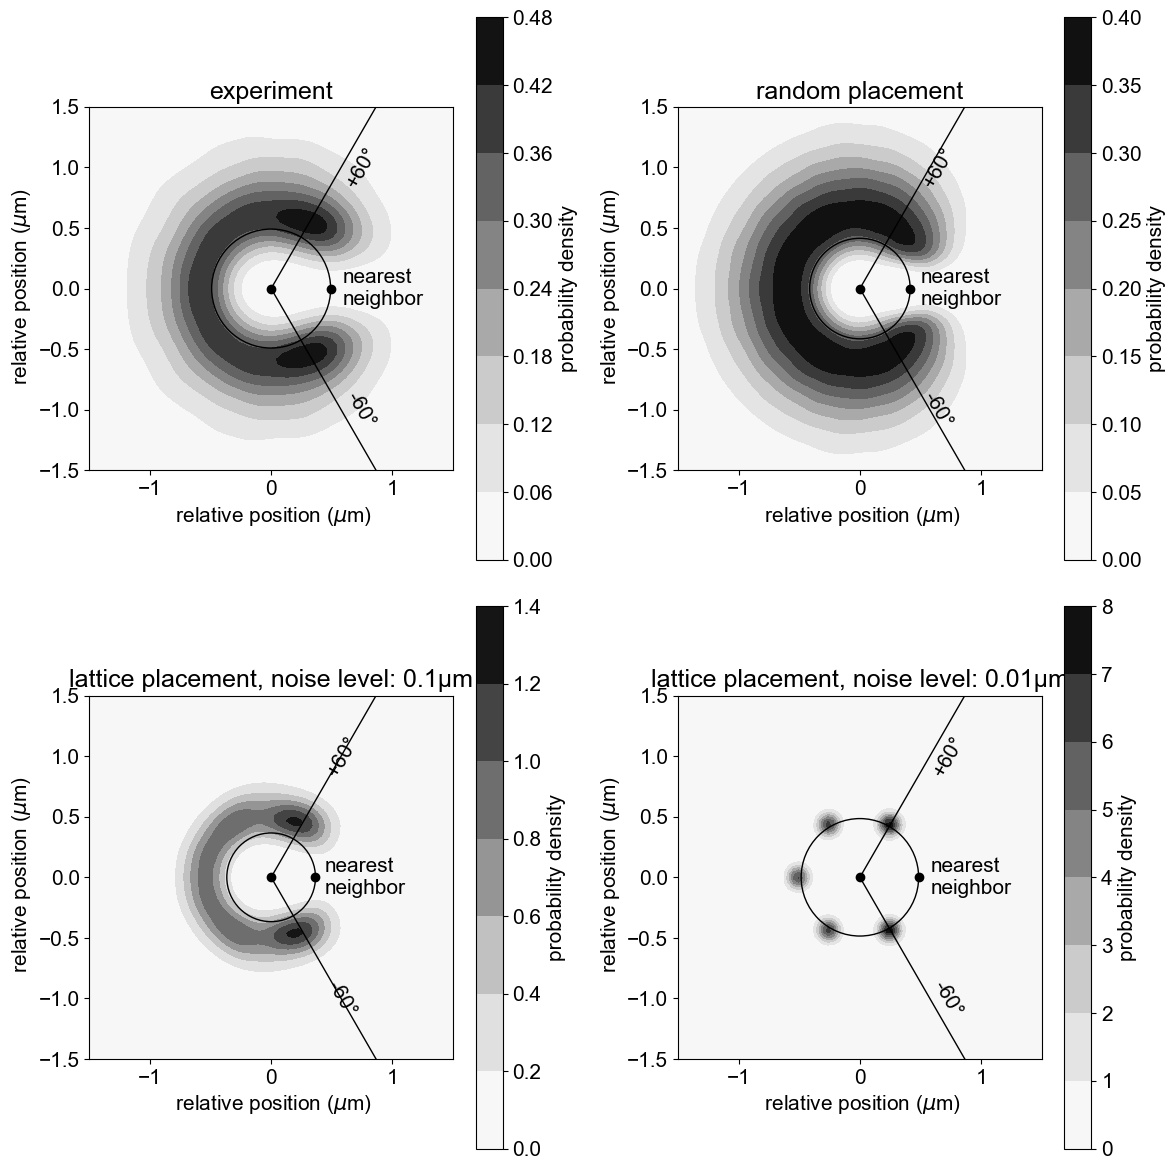

In [5]:
# analyze distributions
num_neighbors_list, nearest_distances, all_distances, rotated_coordinates = analyze_distances(dataset)

# make figure
fig, axs = plt.subplots(2, 2, figsize=(12,12))

# plot experimental data
ax = axs[0, 0]
plot_density(fig, ax, rotated_coordinates['Control'], np.mean(nearest_distances["Control"]), L=2)
ax.set_title("experiment")

# random placement

L = 7.5
R = 0.25
N = 500

num_neighbors_artificial = []
nearest_distances_artificial = []
rotated_coordinates_artificial = []

for _ in range(200):
    points = []
    while len(points) < N:
        x = np.array([random.uniform(-L, L), random.uniform(-L, L)])
        if points == [] or np.all(np.linalg.norm(np.stack(points) - x, axis=-1) > R):
            points.append(x)
    points = np.stack(points)

    num_neighbors_inner, nearest_distances_inner, _, rotated_coordinates_inner = analyze_pointcloud(points)
    num_neighbors_artificial += num_neighbors_inner
    nearest_distances_artificial += nearest_distances_inner
    rotated_coordinates_artificial += rotated_coordinates_inner
    
rotated_coordinates_artificial = np.stack(rotated_coordinates_artificial)
nearest_distances_artificial = np.stack(nearest_distances_artificial)

ax = axs[0, 1]
plot_density(fig, ax, rotated_coordinates_artificial, np.mean(nearest_distances_artificial), L=2)
ax.set_title("random placement")

# lattice placement

for i, noise in enumerate([0.1, 0.01]):
    ax = axs[1, i]

    N = 3

    num_neighbors_artificial = []
    nearest_distances_artificial = []
    rotated_coordinates_artificial = []
    
    for _ in range(500):
        points = np.sqrt(3)/2 * np.array(range(N))
        points = np.stack([0*np.ones(N), points]).T
        points = np.concatenate([points, points + 0.5*np.array([0.5,0.5*np.sqrt(3)])])
        points = np.concatenate([points + i*np.array([0.5, 0]) for i in range(2*N)])
    
        points += noise*np.random.randn(*points.shape)
    
        num_neighbors_inner, nearest_distances_inner, _, rotated_coordinates_inner = analyze_pointcloud(points)
        num_neighbors_artificial += num_neighbors_inner
        nearest_distances_artificial += nearest_distances_inner
        rotated_coordinates_artificial += rotated_coordinates_inner
        
    rotated_coordinates_artificial = np.stack(rotated_coordinates_artificial)
    nearest_distances_artificial = np.stack(nearest_distances_artificial)
    
    plot_density(fig, ax, rotated_coordinates_artificial, np.mean(nearest_distances_artificial), L=2)
    ax.set_title("lattice placement, noise level: "+ str(noise) + "µm")

fig.tight_layout()
fig.savefig("Figures_for_paper/2D_control_positioning.pdf")

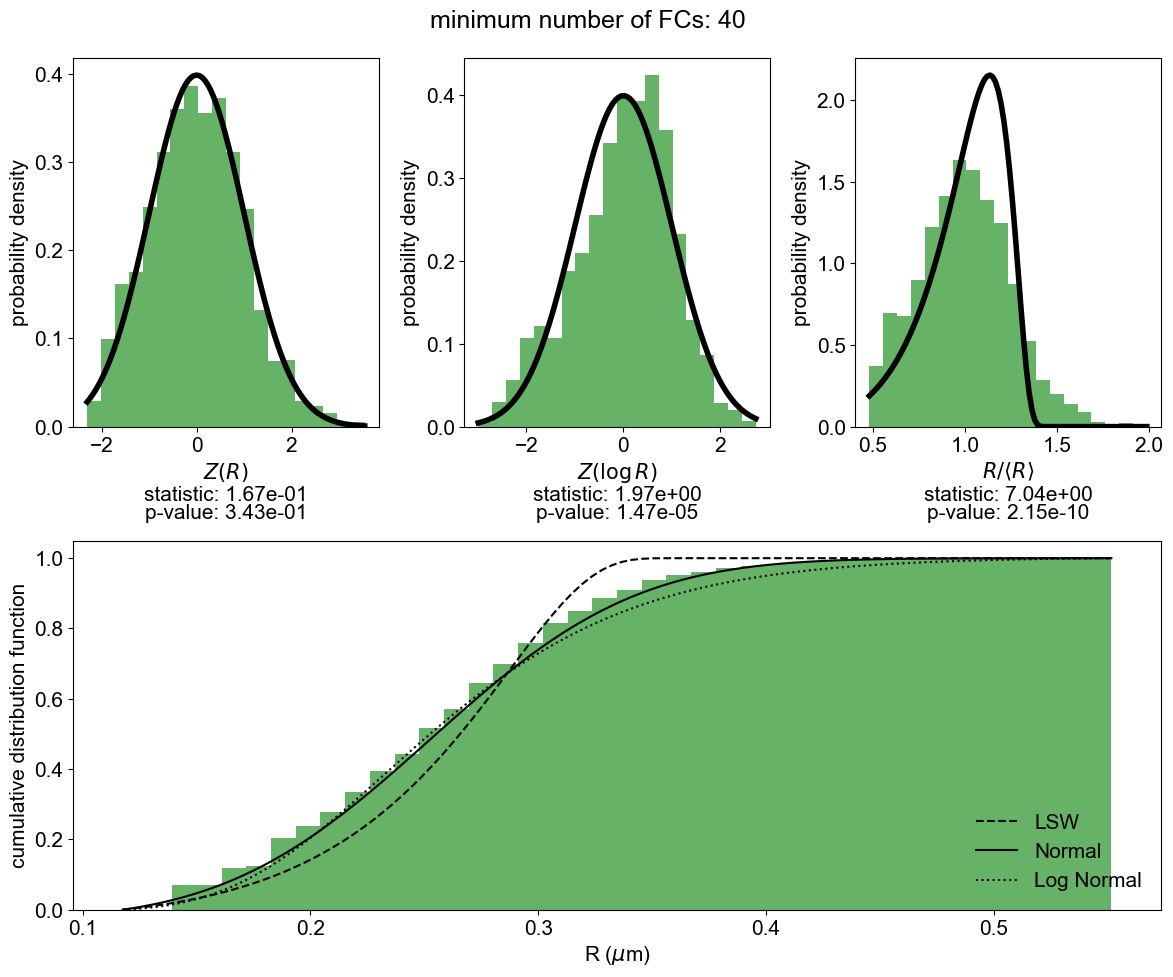

In [6]:
# Plot violin plot of the data
fig, axs = plt.subplots(2, 3, figsize=(12,10))

FC_min_num = 40
normalized_FCs = get_z_scores(dataset, FC_min_num)

fig.suptitle("minimum number of FCs: " + str(FC_min_num))

data = normalized_FCs.loc[normalized_FCs.sample_type=="Control", "z_vals"]
plot_pdf_normalized(axs[0,0], data, scipy.stats.norm, r'$Z(R)$', bins=20)

data = normalized_FCs.loc[normalized_FCs.sample_type=="Control", "z_logs"]
plot_pdf_normalized(axs[0,1], data, scipy.stats.norm, r'$Z(\log R)$', bins=20)

data = normalized_FCs.loc[normalized_FCs.sample_type=="Control", "z_mean"]
plot_pdf_normalized(axs[0,2], data, stats_lsw, r'$R / \langle R \rangle$', bins=20)

for ax in axs[1, 0:]:
    ax.remove()
gs = axs[1, 0].get_gridspec()
axbig = fig.add_subplot(gs[1,0:])
plot_cdf_cutoff(axbig, dataset.loc[dataset.sample_type == "Control", "diameter"])

fig.tight_layout()
fig.savefig("Figures_for_paper/2D_control_distribution.pdf")

# Analysis of fed and starved experiments

In [7]:
micron_per_pixel = 1.0/23.5 # Value from Salman

original = pd.read_csv('Data/feeding_starvation_data.csv')
dataset  = pd.DataFrame()

dataset['spot_id']    = original['spot_id']

# populate a list of FC radii
dataset['radius']     = (original['pixels'] / np.pi)**0.5 * micron_per_pixel
dataset['diameter']   = 2*dataset['radius']

# populate a list of tuples that correspond to the centroid coordinates
dataset['coordinate'] = list(original[['centroid_r', 'centroid_c']].to_numpy() * micron_per_pixel)

# get keywords
dataset["sample"]      = original["sample"]
dataset['sample_type'] = [val[0].capitalize() for val in original['sample'].str.split('-')]

# infer nucleus IDs by clustering
for sample in dataset['sample'].unique():
    mask = dataset['sample'] == sample
    dataset.loc[mask, "nuc_id"] = cluster(np.stack(dataset.loc[mask, 'coordinate']), epsilon = 2.0, min_samples = 3)
dataset["nuc_id"] = dataset["nuc_id"].astype(np.int64)

dataset.head()

,spot_id,radius,diameter,coordinate,sample,sample_type,nuc_id
0,1,0.131498,0.262995,"[0.2127659574468085, 14.76595744680851]",fed-01,Fed,0
1,2,0.142034,0.284067,"[0.5106382978723404, 14.46808510638298]",fed-01,Fed,0
2,3,0.181257,0.362514,"[0.6382978723404256, 15.957446808510637]",fed-01,Fed,0
3,4,0.189040,0.378079,"[0.9361702127659575, 15.319148936170212]",fed-01,Fed,0
4,5,0.115139,0.230277,"[1.0212765957446808, 16.382978723404253]",fed-01,Fed,0


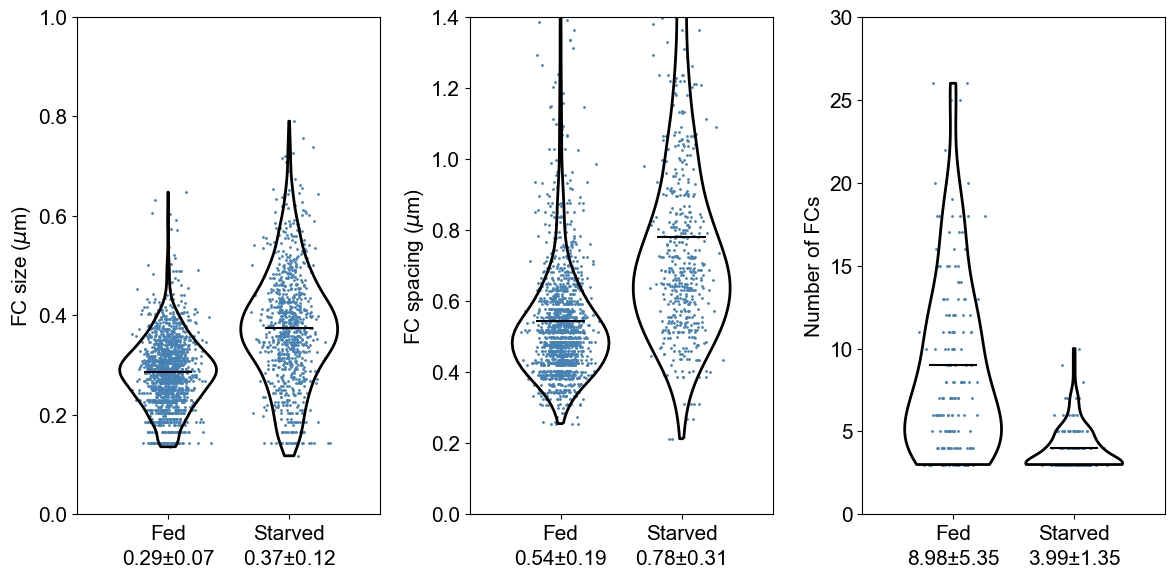

In [8]:
# Plot violin plot of the data
fig, axs = plt.subplots(1, 3, figsize=(12,6))

# plot diameter distribution
diameters = dataset.groupby("sample_type").diameter.apply(list)
plot_violin(axs[0], diameters, r'FC size ($\mu$m)', [0,1.0])

# plot distance distribution
filtered_dataset = dataset[dataset["nuc_id"]>=0]

# In contrast to 3D_Statistics_and_Distribution.ipynb, where nucleoli were called manually,
# here the nucleoli are called by automatic clustering. This can lead to artifacts, where FCs are not part
# of any nucleolus. For that reason, in this notebook I filter out the FCs that are not part of nucleoli
num_neighbors_list, nearest_distances, all_distances, rotated_coordinates = analyze_distances(filtered_dataset)
plot_violin(axs[1], pd.Series(nearest_distances), r'FC spacing ($\mu$m)', [0,1.4])

# plot number of FCs per cluster
cluster_sizes = filtered_dataset.groupby(["sample_type","sample","nuc_id"]).apply(len)
cluster_sizes = cluster_sizes.groupby("sample_type").apply(list)
plot_violin(axs[2], cluster_sizes, r'Number of FCs', [0,30])

# make layout tighter
fig.tight_layout()
fig.savefig("Figures_for_paper/2D_violin_fed_vs_starved.pdf")

# Analysis of TCOF overexpression data

In [9]:
micron_per_pixel = 1.0/23.5 # Value from Salman

original = pd.read_csv('Data/TCOF_overexpression_data.csv')
dataset  = pd.DataFrame()

dataset['spot_id']    = original['spot_id']

# populate a list of FC radii
dataset['radius']     = (original['pixels'] / np.pi)**0.5 * micron_per_pixel
dataset['diameter']   = 2*dataset['radius']

# populate a list of tuples that correspond to the centroid coordinates
dataset['coordinate'] = list(original[['centroid_r', 'centroid_c']].to_numpy() * micron_per_pixel)

# get keywords
dataset["sample"]      = original["sample"]
dataset['sample_type'] = [val[2].capitalize() for val in original['sample'].str.split('-')]

# infer nucleus IDs by clustering
for sample in dataset['sample'].unique():
    mask = dataset['sample'] == sample
    dataset.loc[mask, "nuc_id"] = cluster(np.stack(dataset.loc[mask, 'coordinate']), epsilon = 2.0, min_samples = 3)
dataset["nuc_id"] = dataset["nuc_id"].astype(np.int64)

dataset.head()

,spot_id,radius,diameter,coordinate,sample,sample_type,nuc_id
0,1,0.206525,0.413050,"[0.0851063829787234, 8.51063829787234]",dish1-647FIB1-dox_nega-01,Dox_nega,-1
1,2,0.122418,0.244835,"[0.0425531914893617, 41.48936170212766]",dish1-647FIB1-dox_nega-01,Dox_nega,0
2,3,0.147996,0.295991,"[0.0851063829787234, 43.57446808510638]",dish1-647FIB1-dox_nega-01,Dox_nega,0
3,4,0.131498,0.262995,"[0.0851063829787234, 55.234042553191486]",dish1-647FIB1-dox_nega-01,Dox_nega,1
4,5,0.258575,0.517150,"[0.1702127659574468, 56.5531914893617]",dish1-647FIB1-dox_nega-01,Dox_nega,1


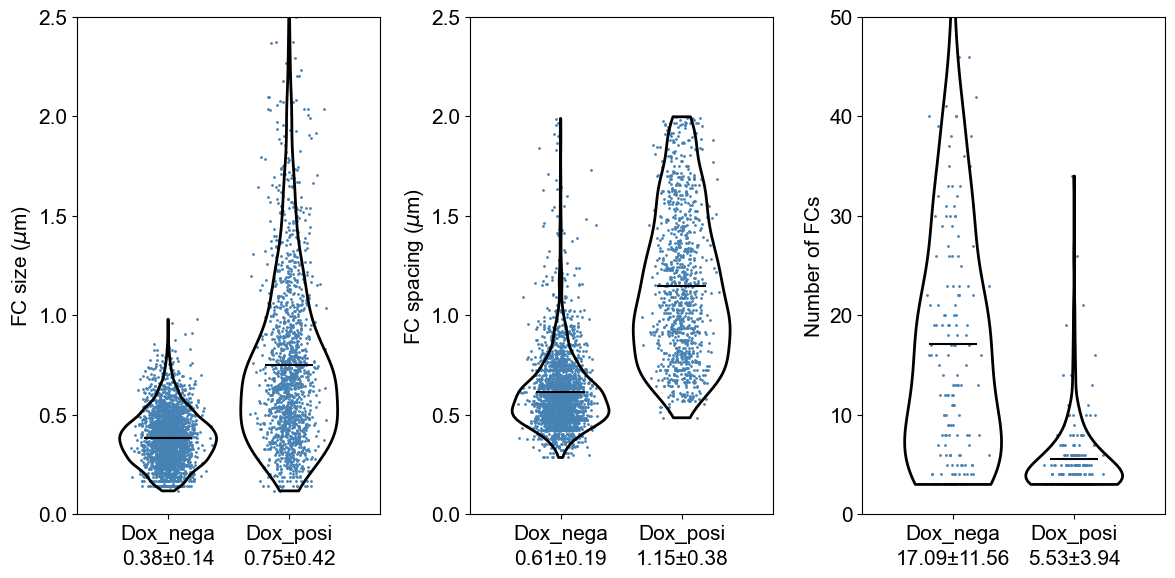

In [10]:
# Plot violin plot of the data
fig, axs = plt.subplots(1, 3, figsize=(12,6))

# plot diameter distribution
diameters = dataset.groupby("sample_type").diameter.apply(list)
plot_violin(axs[0], diameters, r'FC size ($\mu$m)', [0,2.5])

# plot distance distribution
filtered_dataset = dataset[dataset["nuc_id"]>=0]

# In contrast to 3D_Statistics_and_Distribution.ipynb, where nucleoli were called manually,
# here the nucleoli are called by automatic clustering. This can lead to artifacts, where FCs are not part
# of any nucleolus. For that reason, in this notebook I filter out the FCs that are not part of nucleoli
num_neighbors_list, nearest_distances, all_distances, rotated_coordinates = analyze_distances(filtered_dataset)
plot_violin(axs[1], pd.Series(nearest_distances), r'FC spacing ($\mu$m)', [0,2.5])

# plot number of FCs per cluster
cluster_sizes = filtered_dataset.groupby(["sample_type","sample","nuc_id"]).apply(len)
cluster_sizes = cluster_sizes.groupby("sample_type").apply(list)
plot_violin(axs[2], cluster_sizes, r'Number of FCs', [0,50])

# make layout tighter
fig.tight_layout()
fig.savefig("Figures_for_paper/2D_violin_TCOF.pdf")